# 02: Favorites Database Analysis
This notebook dives deeper into aggregates (`COUNT`, `DISTINCT`), grouping (`GROUP BY`), and data visualization of the student survey results.

In [6]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

db_path = os.path.join("..", "databases", "favorites.db")
conn = sqlite3.connect(db_path)

### 1. SQL Aggregations and Grouping
**What SQL concept is demonstrated?**
Using `COUNT(*)` together with `GROUP BY` to aggregate and summarize student favorite languages.

In [7]:
# Query popularity of programming languages
query = """
SELECT language, COUNT(*) AS submissions
FROM favorites
GROUP BY language
ORDER BY submissions DESC;
"""
df_languages = pd.read_sql_query(query, conn)
df_languages

,language,submissions
0,Python,190
1,C,58
2,Scratch,24


### 2. Visualizing Language Popularity
**What SQL concept is demonstrated?**
We load aggregated query outputs into Pandas DataFrames and plot a bar chart to visualize language preferences.

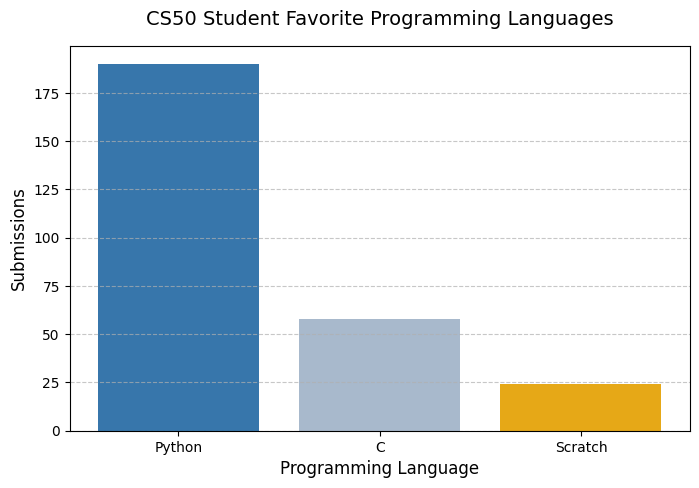

In [8]:
# Plotting language submissions
plt.figure(figsize=(8, 5))
plt.bar(df_languages['language'], df_languages['submissions'], color=['#3776AB', '#A8B9CC', '#E6A817'])
plt.title('CS50 Student Favorite Programming Languages', fontsize=14, pad=15)
plt.xlabel('Programming Language', fontsize=12)
plt.ylabel('Submissions', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 3. Submissions by Problem
**What SQL concept is demonstrated?**
Applying grouping on problem sets to see which problems are most common.

In [9]:
query = """
SELECT problem, COUNT(*) AS count
FROM favorites
GROUP BY problem
ORDER BY count DESC
LIMIT 10;
"""
pd.read_sql_query(query, conn)

,problem,count
0,"Hello, World",42
1,Filter,37
2,Starting from Scratch,27
3,DNA,25
4,Speller,22
5,Mario,21
6,Cash,21
7,Caesar,13
8,Readability,12
9,Tideman,8


In [10]:
conn.close()

### Reflection
**What did I learn?**
- `GROUP BY` collapses duplicate rows into single groups, letting us run aggregations like `COUNT()` per group.
- Combining SQL query results with Python's plotting libraries (like `matplotlib`) allows us to easily transform data tables into visual insights.